# Linear Regression Implementation

This notebook loads the tensor artifacts created in `Make_tensors.ipynb`, builds configurable train/val/test splits, and trains a ridge-style drug-response model with PyTorch Lightning.

Supported split modes:
- `drug_blind`
- `tumor_blind` (implemented here as cell-line-blind)
- `mixed`


In [1]:
from pathlib import Path

SPLIT_MODE = "mixed"  # one of {"drug_blind", "tumor_blind", "mixed"}
SPLIT_FRACTIONS = {"train": 0.8, "val": 0.1, "test": 0.1}
BATCH_SIZE = 512
RANDOM_SEED = 42
NUM_WORKERS = 0

TARGET_MODE = "delta"
PREPROCESS_BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
ACCELERATOR = "auto"
DEVICES = 1
PRECISION = "32-true"

PLOT_TEST_SAMPLE_COUNT = 50
PLOT_TEST_SAMPLE_STRATEGY = "seeded_random"
PLOT_RANDOM_SEED = RANDOM_SEED
EMBEDDING_METHOD = "pca"
N_EMBEDDING_COMPONENTS = 2

TENSOR_ARTIFACTS_DIR = Path("data/Tahoe100M_tensor_artifacts_L1000")
LIGHTNING_OUTPUT_DIR = Path("artifacts/lightning/linear_regression")

print(
    {
        "SPLIT_MODE": SPLIT_MODE,
        "SPLIT_FRACTIONS": SPLIT_FRACTIONS,
        "BATCH_SIZE": BATCH_SIZE,
        "RANDOM_SEED": RANDOM_SEED,
        "NUM_WORKERS": NUM_WORKERS,
        "TARGET_MODE": TARGET_MODE,
        "PREPROCESS_BATCH_SIZE": PREPROCESS_BATCH_SIZE,
        "LEARNING_RATE": LEARNING_RATE,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "MAX_EPOCHS": MAX_EPOCHS,
        "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
        "ACCELERATOR": ACCELERATOR,
        "DEVICES": DEVICES,
        "PRECISION": PRECISION,
        "PLOT_TEST_SAMPLE_COUNT": PLOT_TEST_SAMPLE_COUNT,
        "PLOT_TEST_SAMPLE_STRATEGY": PLOT_TEST_SAMPLE_STRATEGY,
        "PLOT_RANDOM_SEED": PLOT_RANDOM_SEED,
        "EMBEDDING_METHOD": EMBEDDING_METHOD,
        "N_EMBEDDING_COMPONENTS": N_EMBEDDING_COMPONENTS,
        "tumor_blind_behavior": "cell_line_blind",
        "model_family": "ridge_full_only",
    }
)


{'SPLIT_MODE': 'mixed', 'SPLIT_FRACTIONS': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'BATCH_SIZE': 512, 'RANDOM_SEED': 42, 'NUM_WORKERS': 0, 'TARGET_MODE': 'delta', 'PREPROCESS_BATCH_SIZE': 1024, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001, 'MAX_EPOCHS': 50, 'EARLY_STOPPING_PATIENCE': 5, 'ACCELERATOR': 'auto', 'DEVICES': 1, 'PRECISION': '32-true', 'PLOT_TEST_SAMPLE_COUNT': 50, 'PLOT_TEST_SAMPLE_STRATEGY': 'seeded_random', 'PLOT_RANDOM_SEED': 42, 'EMBEDDING_METHOD': 'pca', 'N_EMBEDDING_COMPONENTS': 2, 'tumor_blind_behavior': 'cell_line_blind', 'model_family': 'ridge_full_only'}


## Imports and Helpers


In [2]:
import math

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import seaborn as sns
from scipy.stats import mannwhitneyu
import torch
import torch.nn.functional as F
from IPython.display import display
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from sklearn.decomposition import PCA
from torch import nn
from torch.utils.data import DataLoader, Dataset

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

SPLIT_NAMES = ("train", "val", "test")
SUPPORTED_SPLIT_MODES = {"drug_blind", "tumor_blind", "mixed"}
SUPPORTED_TARGET_MODES = {"delta"}
SUPPORTED_PLOT_SAMPLE_STRATEGIES = {"seeded_random"}
SUPPORTED_EMBEDDING_METHODS = {"pca"}
MIN_STANDARD_DEVIATION = 1e-6


def get_project_root():
    for base_path in [Path.cwd(), *Path.cwd().parents]:
        if (base_path / "pyproject.toml").exists():
            return base_path
    return Path.cwd()


PROJECT_ROOT = get_project_root()


def build_project_path(relative_path):
    path = Path(relative_path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def resolve_target_gene_indices(input_gene_ids, target_gene_ids):
    input_gene_to_index = {str(gene_id): idx for idx, gene_id in enumerate(input_gene_ids)}
    target_gene_indices = []
    missing_target_gene_ids = []

    for gene_id in target_gene_ids:
        normalized_gene_id = str(gene_id)
        if normalized_gene_id not in input_gene_to_index:
            missing_target_gene_ids.append(normalized_gene_id)
        else:
            target_gene_indices.append(input_gene_to_index[normalized_gene_id])

    if missing_target_gene_ids:
        raise ValueError(
            f"Target genes were not found in the DMSO input gene space: {missing_target_gene_ids[:5]}"
        )

    return np.asarray(target_gene_indices, dtype=np.int64)


def resolve_project_path(relative_path):
    candidate_path = build_project_path(relative_path)
    if candidate_path.exists():
        return candidate_path
    raise FileNotFoundError(f"Could not find {relative_path} from {PROJECT_ROOT}")


def load_arrow_table(arrow_path):
    with pa.memory_map(str(arrow_path), "r") as source:
        try:
            return ipc.open_file(source).read_all()
        except pa.ArrowInvalid:
            source.seek(0)
            return ipc.open_stream(source).read_all()


def load_cached_cell_line_metadata():
    arrow_candidates = sorted(
        Path.home().glob(
            ".cache/huggingface/datasets/vevotx___tahoe-100_m/cell_line_metadata/0.0.0/*/tahoe-100_m-train.arrow"
        )
    )
    if not arrow_candidates:
        raise FileNotFoundError(
            "Could not find cached Tahoe cell_line_metadata Arrow file in the Hugging Face cache."
        )

    arrow_path = arrow_candidates[-1]
    raw_df = load_arrow_table(arrow_path).to_pandas().loc[:, ["Cell_ID_Cellosaur", "cell_name", "Organ"]].copy()
    raw_df.columns = ["cell_line", "cell_name", "organ"]

    for column in raw_df.columns:
        raw_df[column] = raw_df[column].astype(str).str.strip()

    consistency_df = raw_df.groupby("cell_line", dropna=False).agg(
        cell_name_nunique=("cell_name", lambda s: s.nunique(dropna=False)),
        organ_nunique=("organ", lambda s: s.nunique(dropna=False)),
    )
    inconsistent_df = consistency_df.loc[
        (consistency_df["cell_name_nunique"] != 1)
        | (consistency_df["organ_nunique"] != 1)
    ]
    if not inconsistent_df.empty:
        raise ValueError(
            "Some Cellosaur IDs map to multiple cell_name/Organ values; cannot build a stable cell-line metadata table."
        )

    cell_line_metadata_df = (
        raw_df.groupby("cell_line", as_index=False, dropna=False)
        .first()
        .sort_values("cell_line", ignore_index=True)
    )
    return cell_line_metadata_df, arrow_path


def validate_split_config(split_mode, split_fractions):
    if split_mode not in SUPPORTED_SPLIT_MODES:
        raise ValueError(f"Unsupported SPLIT_MODE: {split_mode}")

    if set(split_fractions) != set(SPLIT_NAMES):
        raise ValueError(
            f"SPLIT_FRACTIONS must contain exactly {SPLIT_NAMES}; got {tuple(split_fractions)}"
        )

    if any(float(split_fractions[name]) <= 0 for name in SPLIT_NAMES):
        raise ValueError("All split fractions must be positive.")

    total_fraction = sum(float(split_fractions[name]) for name in SPLIT_NAMES)
    if not math.isclose(total_fraction, 1.0, abs_tol=1e-8):
        raise ValueError(f"Split fractions must sum to 1.0; got {total_fraction}")


def validate_training_config(
    target_mode,
    preprocess_batch_size,
    learning_rate,
    weight_decay,
    max_epochs,
    early_stopping_patience,
):
    if target_mode not in SUPPORTED_TARGET_MODES:
        raise ValueError(f"Unsupported TARGET_MODE: {target_mode}")
    if int(preprocess_batch_size) <= 0:
        raise ValueError("PREPROCESS_BATCH_SIZE must be positive.")
    if float(learning_rate) <= 0:
        raise ValueError("LEARNING_RATE must be positive.")
    if float(weight_decay) < 0:
        raise ValueError("WEIGHT_DECAY must be non-negative.")
    if int(max_epochs) <= 0:
        raise ValueError("MAX_EPOCHS must be positive.")
    if int(early_stopping_patience) < 0:
        raise ValueError("EARLY_STOPPING_PATIENCE must be non-negative.")


def validate_plot_config(plot_test_sample_count, plot_test_sample_strategy, embedding_method, n_embedding_components):
    if int(plot_test_sample_count) <= 0:
        raise ValueError("PLOT_TEST_SAMPLE_COUNT must be positive.")
    if plot_test_sample_strategy not in SUPPORTED_PLOT_SAMPLE_STRATEGIES:
        raise ValueError(f"Unsupported PLOT_TEST_SAMPLE_STRATEGY: {plot_test_sample_strategy}")
    if embedding_method not in SUPPORTED_EMBEDDING_METHODS:
        raise ValueError(f"Unsupported EMBEDDING_METHOD: {embedding_method}")
    if int(n_embedding_components) != 2:
        raise ValueError("N_EMBEDDING_COMPONENTS must be 2 for the paired plotting cell.")


def compute_target_row_counts(n_rows, split_fractions):
    val_rows = int(round(float(split_fractions["val"]) * n_rows))
    test_rows = int(round(float(split_fractions["test"]) * n_rows))
    train_rows = int(n_rows - val_rows - test_rows)

    if min(train_rows, val_rows, test_rows) <= 0:
        raise ValueError(
            f"Split fractions produced an empty split: train={train_rows}, val={val_rows}, test={test_rows}"
        )

    return {"train": train_rows, "val": val_rows, "test": test_rows}


def build_row_slices(n_rows, batch_size, min_last_batch_size=1):
    if batch_size <= 0:
        raise ValueError("batch_size must be positive.")

    slices = []
    start = 0
    while start < n_rows:
        end = min(start + batch_size, n_rows)
        slices.append((start, end))
        start = end

    if len(slices) >= 2 and (slices[-1][1] - slices[-1][0]) < min_last_batch_size:
        previous_start, _ = slices[-2]
        _, final_end = slices[-1]
        slices[-2] = (previous_start, final_end)
        slices.pop()

    return slices


def assign_group_blind_splits(frame, group_col, split_fractions, seed):
    target_counts = compute_target_row_counts(len(frame), split_fractions)
    group_sizes = frame.groupby(group_col, dropna=False).size().reset_index(name="row_count")

    rng = np.random.default_rng(seed)
    group_sizes["shuffle_order"] = rng.permutation(len(group_sizes))
    group_sizes = group_sizes.sort_values(
        ["row_count", "shuffle_order"],
        ascending=[False, True],
        kind="stable",
        ignore_index=True,
    )

    assigned_counts = {split_name: 0 for split_name in SPLIT_NAMES}
    group_to_split = {}

    for group_idx, row in group_sizes.iterrows():
        remaining_groups = len(group_sizes) - group_idx
        empty_splits = [split_name for split_name in SPLIT_NAMES if assigned_counts[split_name] == 0]
        if empty_splits and remaining_groups == len(empty_splits):
            candidate_splits = tuple(empty_splits)
        else:
            candidate_splits = SPLIT_NAMES

        group_size = int(row["row_count"])

        def assignment_score(split_name):
            projected = assigned_counts[split_name] + group_size
            target = target_counts[split_name]
            return (
                projected > target,
                abs(target - projected),
                assigned_counts[split_name] / max(target, 1),
                SPLIT_NAMES.index(split_name),
            )

        chosen_split = min(candidate_splits, key=assignment_score)
        group_to_split[row[group_col]] = chosen_split
        assigned_counts[chosen_split] += group_size

    split_series = frame[group_col].map(group_to_split)
    if split_series.isna().any():
        raise ValueError(f"Failed to assign every {group_col} to a split.")

    return split_series.astype(str)


def assign_mixed_split(frame, split_fractions, seed):
    target_counts = compute_target_row_counts(len(frame), split_fractions)
    split_assignments = np.full(len(frame), "train", dtype=object)
    remaining_drug_counts = frame["drug"].value_counts().to_dict()
    remaining_cell_line_counts = frame["cell_line"].value_counts().to_dict()
    drugs = frame["drug"].to_numpy()
    cell_lines = frame["cell_line"].to_numpy()

    rng = np.random.default_rng(seed)
    for split_name in ("val", "test"):
        target_rows = target_counts[split_name]
        assigned_rows = 0

        for row_idx in rng.permutation(len(frame)):
            if split_assignments[row_idx] != "train":
                continue

            drug = drugs[row_idx]
            cell_line = cell_lines[row_idx]
            if remaining_drug_counts[drug] <= 1 or remaining_cell_line_counts[cell_line] <= 1:
                continue

            split_assignments[row_idx] = split_name
            remaining_drug_counts[drug] -= 1
            remaining_cell_line_counts[cell_line] -= 1
            assigned_rows += 1

            if assigned_rows >= target_rows:
                break

        if assigned_rows < target_rows:
            raise ValueError(
                f"Could only assign {assigned_rows} rows to {split_name} while preserving train coverage for every drug and cell_line."
            )

    return pd.Series(split_assignments, index=frame.index, name="split")


def build_split_summary(split_frame, split_fractions):
    target_counts = compute_target_row_counts(len(split_frame), split_fractions)
    summary_rows = []

    for split_name in SPLIT_NAMES:
        subset = split_frame.loc[split_frame["split"] == split_name].copy()
        summary_rows.append(
            {
                "split": split_name,
                "target_rows": target_counts[split_name],
                "row_count": int(len(subset)),
                "requested_fraction": float(split_fractions[split_name]),
                "realized_fraction": float(len(subset) / len(split_frame)),
                "unique_drugs": int(subset["drug"].nunique()),
                "unique_cell_lines": int(subset["cell_line"].nunique()),
                "unique_organs": int(subset["organ"].nunique()),
            }
        )

    return pd.DataFrame(summary_rows)


def build_overlap_diagnostics(split_frame, split_mode):
    if split_mode == "drug_blind":
        entity_columns = ("drug", "condition_key", "cell_line")
    elif split_mode == "tumor_blind":
        entity_columns = ("cell_line", "condition_key", "drug")
    else:
        entity_columns = ("condition_key", "drug", "cell_line")

    split_sets = {
        split_name: {
            column: set(split_frame.loc[split_frame["split"] == split_name, column])
            for column in entity_columns
        }
        for split_name in SPLIT_NAMES
    }

    rows = []
    for column in entity_columns:
        for left_split, right_split in (("train", "val"), ("train", "test"), ("val", "test")):
            rows.append(
                {
                    "entity": column,
                    "pair": f"{left_split}/{right_split}",
                    "overlap_count": len(split_sets[left_split][column] & split_sets[right_split][column]),
                }
            )

    return pd.DataFrame(rows)


def validate_split_assignments(split_frame, split_mode):
    if split_frame["condition_key"].duplicated().any():
        raise ValueError("condition_key values must remain unique after splitting.")

    if set(split_frame["split"]) != set(SPLIT_NAMES):
        raise ValueError("Every split must contain at least one row.")

    if split_mode == "drug_blind":
        split_sets = {
            split_name: set(split_frame.loc[split_frame["split"] == split_name, "drug"])
            for split_name in SPLIT_NAMES
        }
        for left_split, right_split in (("train", "val"), ("train", "test"), ("val", "test")):
            if split_sets[left_split] & split_sets[right_split]:
                raise ValueError("drug_blind split leaked drugs across splits.")

    elif split_mode == "tumor_blind":
        split_sets = {
            split_name: set(split_frame.loc[split_frame["split"] == split_name, "cell_line"])
            for split_name in SPLIT_NAMES
        }
        for left_split, right_split in (("train", "val"), ("train", "test"), ("val", "test")):
            if split_sets[left_split] & split_sets[right_split]:
                raise ValueError("tumor_blind split leaked cell lines across splits.")

    else:
        condition_key_sets = {
            split_name: set(split_frame.loc[split_frame["split"] == split_name, "condition_key"])
            for split_name in SPLIT_NAMES
        }
        for left_split, right_split in (("train", "val"), ("train", "test"), ("val", "test")):
            if condition_key_sets[left_split] & condition_key_sets[right_split]:
                raise ValueError("mixed split leaked condition keys across splits.")

        train_frame = split_frame.loc[split_frame["split"] == "train"]
        if set(train_frame["drug"]) != set(split_frame["drug"]):
            raise ValueError("mixed split must retain every drug in train.")
        if set(train_frame["cell_line"]) != set(split_frame["cell_line"]):
            raise ValueError("mixed split must retain every cell line in train.")


class TreatmentExampleDataset(Dataset):
    def __init__(self, examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle):
        self.examples_df = examples_df.reset_index(drop=True).copy()
        self.dmso_bundle = dmso_bundle
        self.treatment_bundle = treatment_bundle
        self.fingerprint_bundle = fingerprint_bundle

    def __len__(self):
        return len(self.examples_df)

    def __getitem__(self, idx):
        row = self.examples_df.iloc[idx]
        baseline_index = int(row["baseline_index"])
        fingerprint_index = int(row["fingerprint_index"])
        target_index = int(row["target_index"])

        return {
            "baseline_expression": self.dmso_bundle["expressions"][baseline_index],
            "drug_fingerprint": self.fingerprint_bundle["fingerprints"][fingerprint_index],
            "concentration": torch.tensor(float(row["concentration"]), dtype=torch.float32),
            "target_expression": self.treatment_bundle["expressions"][target_index],
            "condition_key": row["condition_key"],
            "cell_line": row["cell_line"],
            "cell_name": row["cell_name"],
            "organ": row["organ"],
            "drug": row["drug"],
            "concentration_unit": row["concentration_unit"],
        }


class TrainingPreprocessor:
    def __init__(
        self,
        train_examples_df,
        dmso_bundle,
        treatment_bundle,
        fingerprint_bundle,
        target_gene_indices,
        target_mode,
        batch_size,
    ):
        self.train_examples_df = train_examples_df.reset_index(drop=True).copy()
        self.dmso_input_expression_lookup = dmso_bundle["expressions"].detach().cpu().to(torch.float32).contiguous()
        self.treatment_expression_lookup = treatment_bundle["expressions"].detach().cpu().to(torch.float32).contiguous()
        self.fingerprint_lookup = fingerprint_bundle["fingerprints"].detach().cpu().to(torch.float32).contiguous()
        self.target_gene_indices = torch.as_tensor(np.asarray(target_gene_indices, dtype=np.int64), dtype=torch.long)
        self.dmso_target_expression_lookup = self.dmso_input_expression_lookup.index_select(1, self.target_gene_indices).contiguous()
        self.target_mode = str(target_mode)
        self.batch_size = int(batch_size)
        self.input_gene_dim = int(self.dmso_input_expression_lookup.shape[1])
        self.target_gene_dim = int(self.treatment_expression_lookup.shape[1])
        self.gene_dim = int(self.target_gene_dim)
        self.fingerprint_dim = int(self.fingerprint_lookup.shape[1])
        self.input_dim = int(self.input_gene_dim + self.fingerprint_dim + 1)
        self.delta_mean = None
        self.delta_std = None
        self.baseline_mean = None
        self.baseline_std = None
        self.dose_log_mean = None
        self.dose_log_std = None
        self.normalized_dmso_input_expression_lookup = None

        if self.dmso_target_expression_lookup.shape[1] != self.target_gene_dim:
            raise ValueError("Resolved target gene indices do not match the treatment target width.")

    def _iter_train_batches(self):
        for start, end in build_row_slices(
            len(self.train_examples_df),
            batch_size=self.batch_size,
            min_last_batch_size=1,
        ):
            yield self.train_examples_df.iloc[start:end]

    def _get_input_baseline_batch(self, batch_df):
        baseline_indices = torch.as_tensor(batch_df["baseline_index"].to_numpy(np.int64), dtype=torch.long)
        return self.dmso_input_expression_lookup[baseline_indices]

    def _get_target_baseline_batch(self, batch_df):
        baseline_indices = torch.as_tensor(batch_df["baseline_index"].to_numpy(np.int64), dtype=torch.long)
        return self.dmso_target_expression_lookup[baseline_indices]

    def _get_delta_batch(self, batch_df):
        baseline_batch = self._get_target_baseline_batch(batch_df)
        target_indices = torch.as_tensor(batch_df["target_index"].to_numpy(np.int64), dtype=torch.long)
        target_batch = self.treatment_expression_lookup[target_indices]
        return target_batch - baseline_batch

    def fit(self):
        train_count = len(self.train_examples_df)
        if train_count <= 1:
            raise ValueError("Need at least two training examples to fit the preprocessor.")

        baseline_sum = torch.zeros(self.input_gene_dim, dtype=torch.float64)
        baseline_sq_sum = torch.zeros(self.input_gene_dim, dtype=torch.float64)
        for batch_df in self._iter_train_batches():
            baseline_batch = self._get_input_baseline_batch(batch_df).to(torch.float64)
            baseline_sum += baseline_batch.sum(dim=0)
            baseline_sq_sum += baseline_batch.square().sum(dim=0)

        baseline_mean = baseline_sum / train_count
        baseline_var = baseline_sq_sum / train_count - baseline_mean.square()
        baseline_std = torch.sqrt(torch.clamp(baseline_var, min=MIN_STANDARD_DEVIATION))
        self.baseline_mean = baseline_mean.to(torch.float32)
        self.baseline_std = baseline_std.to(torch.float32)
        self.normalized_dmso_input_expression_lookup = (
            (self.dmso_input_expression_lookup - self.baseline_mean) / self.baseline_std
        ).to(torch.float32)

        dose_values = self.train_examples_df["concentration"].to_numpy(np.float32)
        dose_log_values = np.log10(np.clip(dose_values, a_min=MIN_STANDARD_DEVIATION, a_max=None))
        self.dose_log_mean = torch.tensor(float(dose_log_values.mean()), dtype=torch.float32)
        self.dose_log_std = torch.tensor(
            float(max(dose_log_values.std(), MIN_STANDARD_DEVIATION)),
            dtype=torch.float32,
        )

        delta_sum = torch.zeros(self.target_gene_dim, dtype=torch.float64)
        delta_sq_sum = torch.zeros(self.target_gene_dim, dtype=torch.float64)
        for batch_df in self._iter_train_batches():
            delta_batch = self._get_delta_batch(batch_df).to(torch.float64)
            delta_sum += delta_batch.sum(dim=0)
            delta_sq_sum += delta_batch.square().sum(dim=0)

        delta_mean = delta_sum / train_count
        delta_var = delta_sq_sum / train_count - delta_mean.square()
        delta_std = torch.sqrt(torch.clamp(delta_var, min=MIN_STANDARD_DEVIATION))
        self.delta_mean = delta_mean.to(torch.float32)
        self.delta_std = delta_std.to(torch.float32)
        return self

    def summary_frame(self):
        return pd.DataFrame(
            [
                {
                    "target_mode": self.target_mode,
                    "train_examples": int(len(self.train_examples_df)),
                    "input_dim": int(self.input_dim),
                    "input_gene_dim": int(self.input_gene_dim),
                    "target_gene_dim": int(self.target_gene_dim),
                    "fingerprint_dim": int(self.fingerprint_dim),
                    "dose_log_mean": float(self.dose_log_mean.item()),
                    "dose_log_std": float(self.dose_log_std.item()),
                    "baseline_std_min": float(self.baseline_std.min().item()),
                    "delta_std_min": float(self.delta_std.min().item()),
                }
            ]
        )


class PreparedTreatmentDataset(Dataset):
    def __init__(self, examples_df, preprocessor):
        self.examples_df = examples_df.reset_index(drop=True).copy()
        self.preprocessor = preprocessor
        self.condition_keys = self.examples_df["condition_key"].tolist()
        self.cell_lines = self.examples_df["cell_line"].tolist()
        self.cell_names = self.examples_df["cell_name"].tolist()
        self.organs = self.examples_df["organ"].tolist()
        self.drugs = self.examples_df["drug"].tolist()
        self.concentration_units = self.examples_df["concentration_unit"].tolist()
        self.concentrations = torch.tensor(
            self.examples_df["concentration"].to_numpy(np.float32),
            dtype=torch.float32,
        )
        self.scaled_doses = (
            (torch.log10(torch.clamp(self.concentrations, min=MIN_STANDARD_DEVIATION)) - self.preprocessor.dose_log_mean)
            / self.preprocessor.dose_log_std
        ).to(torch.float32)
        self.baseline_indices = torch.tensor(
            self.examples_df["baseline_index"].to_numpy(np.int64),
            dtype=torch.long,
        )
        self.fingerprint_indices = torch.tensor(
            self.examples_df["fingerprint_index"].to_numpy(np.int64),
            dtype=torch.long,
        )
        self.target_indices = torch.tensor(
            self.examples_df["target_index"].to_numpy(np.int64),
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.examples_df)

    def __getitem__(self, idx):
        baseline_index = int(self.baseline_indices[idx])
        fingerprint_index = int(self.fingerprint_indices[idx])
        target_index = int(self.target_indices[idx])

        baseline_expression = self.preprocessor.dmso_target_expression_lookup[baseline_index]
        target_expression = self.preprocessor.treatment_expression_lookup[target_index]
        target_delta = target_expression - baseline_expression
        normalized_baseline = self.preprocessor.normalized_dmso_input_expression_lookup[baseline_index]
        fingerprint = self.preprocessor.fingerprint_lookup[fingerprint_index]
        input_features = torch.cat(
            [normalized_baseline, fingerprint, self.scaled_doses[idx].view(1)],
            dim=0,
        )

        return {
            "dataset_index": int(idx),
            "input_features": input_features,
            "baseline_expression": baseline_expression,
            "target_delta": target_delta,
            "concentration": self.concentrations[idx],
            "condition_key": self.condition_keys[idx],
            "cell_line": self.cell_lines[idx],
            "cell_name": self.cell_names[idx],
            "organ": self.organs[idx],
            "drug": self.drugs[idx],
            "concentration_unit": self.concentration_units[idx],
        }


class RidgeResponseDataModule(L.LightningDataModule):
    def __init__(
        self,
        train_examples_df,
        val_examples_df,
        test_examples_df,
        preprocessor,
        batch_size,
        num_workers,
        seed,
    ):
        super().__init__()
        self.train_examples_df = train_examples_df.reset_index(drop=True).copy()
        self.val_examples_df = val_examples_df.reset_index(drop=True).copy()
        self.test_examples_df = test_examples_df.reset_index(drop=True).copy()
        self.preprocessor = preprocessor
        self.batch_size = int(batch_size)
        self.num_workers = int(num_workers)
        self.seed = int(seed)
        self.pin_memory = bool(torch.cuda.is_available())
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None

    def setup(self, stage=None):
        if self.train_dataset is None:
            self.train_dataset = PreparedTreatmentDataset(self.train_examples_df, self.preprocessor)
        if self.val_dataset is None:
            self.val_dataset = PreparedTreatmentDataset(self.val_examples_df, self.preprocessor)
        if self.test_dataset is None:
            self.test_dataset = PreparedTreatmentDataset(self.test_examples_df, self.preprocessor)

    def _make_loader(self, dataset, shuffle):
        loader_kwargs = {
            "dataset": dataset,
            "batch_size": self.batch_size,
            "shuffle": shuffle,
            "num_workers": self.num_workers,
            "drop_last": False,
            "pin_memory": self.pin_memory,
            "persistent_workers": self.num_workers > 0,
        }
        if shuffle:
            loader_kwargs["generator"] = torch.Generator().manual_seed(self.seed)
        return DataLoader(**loader_kwargs)

    def train_dataloader(self):
        return self._make_loader(self.train_dataset, shuffle=True)

    def train_eval_dataloader(self):
        return self._make_loader(self.train_dataset, shuffle=False)

    def val_dataloader(self):
        return self._make_loader(self.val_dataset, shuffle=False)

    def test_dataloader(self):
        return self._make_loader(self.test_dataset, shuffle=False)


class RidgeDrugResponseModule(L.LightningModule):
    def __init__(
        self,
        input_dim,
        gene_dim,
        learning_rate,
        weight_decay,
        delta_mean,
        delta_std,
    ):
        super().__init__()
        self.save_hyperparameters(
            {
                "input_dim": int(input_dim),
                "gene_dim": int(gene_dim),
                "learning_rate": float(learning_rate),
                "weight_decay": float(weight_decay),
            }
        )
        self.input_dim = int(input_dim)
        self.gene_dim = int(gene_dim)
        self.output_dim = int(gene_dim)
        self.learning_rate = float(learning_rate)
        self.weight_decay = float(weight_decay)
        self.register_buffer("delta_mean", delta_mean.to(torch.float32))
        self.register_buffer("delta_std", delta_std.to(torch.float32))
        self.linear = nn.Linear(self.input_dim, self.output_dim)

    def forward(self, input_features):
        standardized_delta = self.linear(input_features)
        return standardized_delta * self.delta_std + self.delta_mean

    def _shared_step(self, batch, stage):
        predicted_delta = self(batch["input_features"])
        target_delta = batch["target_delta"]
        predicted_expression = batch["baseline_expression"] + predicted_delta
        target_expression = batch["baseline_expression"] + target_delta
        loss = F.mse_loss(predicted_delta, target_delta)
        delta_mae = F.l1_loss(predicted_delta, target_delta)
        treated_cosine = F.cosine_similarity(predicted_expression, target_expression, dim=1).mean()

        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=stage != "train", batch_size=target_delta.shape[0])
        self.log(f"{stage}_delta_mse", loss, on_step=False, on_epoch=True, batch_size=target_delta.shape[0])
        self.log(f"{stage}_delta_mae", delta_mae, on_step=False, on_epoch=True, batch_size=target_delta.shape[0])
        self.log(f"{stage}_treated_cosine", treated_cosine, on_step=False, on_epoch=True, prog_bar=stage != "train", batch_size=target_delta.shape[0])
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        decay_params = []
        no_decay_params = []
        for name, parameter in self.named_parameters():
            if not parameter.requires_grad:
                continue
            if name.endswith("bias"):
                no_decay_params.append(parameter)
            else:
                decay_params.append(parameter)

        optimizer = torch.optim.AdamW(
            [
                {"params": decay_params, "weight_decay": self.weight_decay},
                {"params": no_decay_params, "weight_decay": 0.0},
            ],
            lr=self.learning_rate,
        )
        return optimizer


def count_trainable_parameters(model):
    return int(sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))


def estimate_adamw_memory_gb(model):
    parameter_count = count_trainable_parameters(model)
    approximate_bytes = parameter_count * 4 * 4
    return float(approximate_bytes / (1024 ** 3))


def move_batch_to_device(batch, device):
    moved_batch = {}
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            moved_batch[key] = value.to(device)
        else:
            moved_batch[key] = value
    return moved_batch


def compute_mann_whitney_batch(predicted_expression, target_expression):
    predicted_expression_np = predicted_expression.detach().cpu().numpy()
    target_expression_np = target_expression.detach().cpu().numpy()
    mann_whitney_u_values = []
    mann_whitney_pvalues = []

    for predicted_row, target_row in zip(predicted_expression_np, target_expression_np):
        mann_whitney_result = mannwhitneyu(
            predicted_row,
            target_row,
            alternative="two-sided",
            method="asymptotic",
        )
        mann_whitney_u_values.append(float(mann_whitney_result.statistic))
        mann_whitney_pvalues.append(float(mann_whitney_result.pvalue))

    return (
        np.asarray(mann_whitney_u_values, dtype=np.float64),
        np.asarray(mann_whitney_pvalues, dtype=np.float64),
    )


def evaluate_model_on_loader(
    model,
    loader,
    split_name,
    gene_ids,
    max_inspection_rows=3,
    n_inspection_genes=5,
    mann_whitney_alpha=0.05,
):
    device = next(model.parameters()).device
    selected_gene_ids = list(gene_ids[:n_inspection_genes])
    total_rows = 0
    delta_mse_sum = 0.0
    delta_mae_sum = 0.0
    treated_cosine_sum = 0.0
    mann_whitney_u_values = []
    mann_whitney_pvalues = []
    inspection_rows = []
    prediction_detail_rows = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            predicted_delta = model(batch["input_features"])
            target_delta = batch["target_delta"]
            predicted_expression = batch["baseline_expression"] + predicted_delta
            target_expression = batch["baseline_expression"] + target_delta

            per_sample_delta_mse = torch.mean((predicted_delta - target_delta) ** 2, dim=1)
            per_sample_delta_mae = torch.mean(torch.abs(predicted_delta - target_delta), dim=1)
            per_sample_treated_mse = torch.mean((predicted_expression - target_expression) ** 2, dim=1)
            per_sample_treated_cosine = F.cosine_similarity(predicted_expression, target_expression, dim=1)
            per_sample_mann_whitney_u, per_sample_mann_whitney_pvalue = compute_mann_whitney_batch(
                predicted_expression,
                target_expression,
            )

            batch_rows = int(target_delta.shape[0])
            total_rows += batch_rows
            delta_mse_sum += float(per_sample_delta_mse.sum().item())
            delta_mae_sum += float(per_sample_delta_mae.sum().item())
            treated_cosine_sum += float(per_sample_treated_cosine.sum().item())
            mann_whitney_u_values.extend(per_sample_mann_whitney_u.tolist())
            mann_whitney_pvalues.extend(per_sample_mann_whitney_pvalue.tolist())

            rows_needed = max(0, max_inspection_rows - len(inspection_rows))
            for row_idx in range(min(rows_needed, batch_rows)):
                inspection_row = {
                    "split": split_name,
                    "condition_key": batch["condition_key"][row_idx],
                    "cell_line": batch["cell_line"][row_idx],
                    "drug": batch["drug"][row_idx],
                    "concentration": float(batch["concentration"][row_idx].detach().cpu().item()),
                    "sample_delta_mse": float(per_sample_delta_mse[row_idx].detach().cpu().item()),
                    "sample_treated_cosine": float(per_sample_treated_cosine[row_idx].detach().cpu().item()),
                    "sample_mann_whitney_u": float(per_sample_mann_whitney_u[row_idx]),
                    "sample_mann_whitney_pvalue": float(per_sample_mann_whitney_pvalue[row_idx]),
                }
                for gene_offset, gene_id in enumerate(selected_gene_ids):
                    inspection_row[f"pred_{gene_id}"] = float(predicted_expression[row_idx, gene_offset].detach().cpu().item())
                    inspection_row[f"target_{gene_id}"] = float(target_expression[row_idx, gene_offset].detach().cpu().item())
                inspection_rows.append(inspection_row)

            dataset_indices = batch["dataset_index"].detach().cpu().numpy()
            concentrations = batch["concentration"].detach().cpu().numpy()
            delta_mse_values = per_sample_delta_mse.detach().cpu().numpy()
            delta_mae_values = per_sample_delta_mae.detach().cpu().numpy()
            treated_mse_values = per_sample_treated_mse.detach().cpu().numpy()
            treated_cosine_values = per_sample_treated_cosine.detach().cpu().numpy()
            for row_idx in range(batch_rows):
                prediction_detail_rows.append(
                    {
                        "split": split_name,
                        "dataset_index": int(dataset_indices[row_idx]),
                        "condition_key": batch["condition_key"][row_idx],
                        "cell_line": batch["cell_line"][row_idx],
                        "cell_name": batch["cell_name"][row_idx],
                        "organ": batch["organ"][row_idx],
                        "drug": batch["drug"][row_idx],
                        "concentration": float(concentrations[row_idx]),
                        "concentration_unit": batch["concentration_unit"][row_idx],
                        "delta_mse": float(delta_mse_values[row_idx]),
                        "delta_mae": float(delta_mae_values[row_idx]),
                        "treated_mse": float(treated_mse_values[row_idx]),
                        "treated_cosine": float(treated_cosine_values[row_idx]),
                        "mann_whitney_u": float(per_sample_mann_whitney_u[row_idx]),
                        "mann_whitney_pvalue": float(per_sample_mann_whitney_pvalue[row_idx]),
                    }
                )

    mann_whitney_u_values = np.asarray(mann_whitney_u_values, dtype=np.float64)
    mann_whitney_pvalues = np.asarray(mann_whitney_pvalues, dtype=np.float64)

    metrics = {
        "split": split_name,
        "n_samples": int(total_rows),
        "delta_mse": float(delta_mse_sum / max(total_rows, 1)),
        "delta_mae": float(delta_mae_sum / max(total_rows, 1)),
        "treated_cosine": float(treated_cosine_sum / max(total_rows, 1)),
        "mann_whitney_u_median": float(np.median(mann_whitney_u_values)) if total_rows else float("nan"),
        "mann_whitney_pvalue_mean": float(np.mean(mann_whitney_pvalues)) if total_rows else float("nan"),
        "mann_whitney_pvalue_median": float(np.median(mann_whitney_pvalues)) if total_rows else float("nan"),
        "mann_whitney_not_significant_fraction": float(np.mean(mann_whitney_pvalues >= mann_whitney_alpha)) if total_rows else float("nan"),
    }
    inspection_df = pd.DataFrame(inspection_rows)
    prediction_details_df = pd.DataFrame(prediction_detail_rows)
    return metrics, inspection_df, prediction_details_df


def load_lightning_metrics_table(metrics_csv_path):
    metrics_csv_path = Path(metrics_csv_path)
    if not metrics_csv_path.exists():
        raise FileNotFoundError(f"Could not find Lightning metrics file: {metrics_csv_path}")

    metrics_df = pd.read_csv(metrics_csv_path)
    if metrics_df.empty:
        raise ValueError("Lightning metrics.csv is empty.")
    if "epoch" not in metrics_df.columns:
        raise ValueError("Lightning metrics.csv does not contain an epoch column.")
    return metrics_df


def build_loss_history_table(metrics_df):
    history_frames = []
    for split_name, loss_column in (("train", "train_loss"), ("val", "val_loss")):
        if loss_column not in metrics_df.columns:
            continue
        subset = metrics_df.loc[metrics_df[loss_column].notna(), ["epoch", "step", loss_column]].copy()
        if subset.empty:
            continue
        subset = subset.sort_values(["epoch", "step"], kind="stable")
        subset = subset.groupby("epoch", as_index=False)[loss_column].last()
        subset = subset.rename(columns={loss_column: "loss"})
        subset["split"] = split_name
        history_frames.append(subset)

    if not history_frames:
        raise ValueError("Could not extract any epoch-level train/val loss values from Lightning metrics.csv.")

    loss_history_df = pd.concat(history_frames, ignore_index=True)
    loss_history_df["epoch"] = loss_history_df["epoch"].astype(int)
    return loss_history_df.sort_values(["epoch", "split"], ignore_index=True)


def sample_prediction_details(prediction_details_df, sample_count, sample_strategy, random_seed):
    if prediction_details_df.empty:
        raise ValueError("prediction_details_df is empty; there are no rows to sample.")
    if sample_strategy != "seeded_random":
        raise ValueError(f"Unsupported sample strategy: {sample_strategy}")

    effective_sample_count = min(int(sample_count), int(len(prediction_details_df)))
    sampled_df = prediction_details_df.sample(
        n=effective_sample_count,
        replace=False,
        random_state=int(random_seed),
    )
    sampled_df = sampled_df.sort_values(["dataset_index", "condition_key"], kind="stable").reset_index(drop=True)
    sampled_df["pair_index"] = np.arange(1, len(sampled_df) + 1, dtype=int)
    return sampled_df


def build_prediction_pair_embedding(model, dataset, sampled_prediction_details_df, embedding_method, n_components, random_seed):
    if embedding_method != "pca":
        raise ValueError(f"Unsupported embedding method: {embedding_method}")
    if sampled_prediction_details_df.empty:
        raise ValueError("No sampled prediction details were provided for embedding.")

    device = next(model.parameters()).device
    selected_examples = [dataset[int(dataset_index)] for dataset_index in sampled_prediction_details_df["dataset_index"].tolist()]
    input_features = torch.stack([example["input_features"] for example in selected_examples], dim=0).to(device)
    baseline_expression = torch.stack([example["baseline_expression"] for example in selected_examples], dim=0).to(device)
    target_delta = torch.stack([example["target_delta"] for example in selected_examples], dim=0).to(device)

    model.eval()
    with torch.no_grad():
        predicted_delta = model(input_features)
        predicted_expression = baseline_expression + predicted_delta
        actual_expression = baseline_expression + target_delta

    predicted_expression_np = predicted_expression.detach().cpu().numpy()
    actual_expression_np = actual_expression.detach().cpu().numpy()
    combined_expression_np = np.concatenate([actual_expression_np, predicted_expression_np], axis=0)
    embedding_model = PCA(n_components=int(n_components), svd_solver="full")
    embedded_points = embedding_model.fit_transform(combined_expression_np)

    n_pairs = len(sampled_prediction_details_df)
    actual_points = embedded_points[:n_pairs]
    predicted_points = embedded_points[n_pairs:]
    explained_variance_ratio = embedding_model.explained_variance_ratio_

    plot_rows = []
    pair_summary_rows = []
    for row_idx, metadata_row in sampled_prediction_details_df.reset_index(drop=True).iterrows():
        actual_point = actual_points[row_idx]
        predicted_point = predicted_points[row_idx]
        pair_distance_2d = float(np.linalg.norm(actual_point - predicted_point))

        for point_kind, point_values in (("actual", actual_point), ("predicted", predicted_point)):
            plot_rows.append(
                {
                    "pair_index": int(metadata_row["pair_index"]),
                    "point_kind": point_kind,
                    "embedding_1": float(point_values[0]),
                    "embedding_2": float(point_values[1]),
                    "condition_key": metadata_row["condition_key"],
                    "cell_line": metadata_row["cell_line"],
                    "drug": metadata_row["drug"],
                    "concentration": float(metadata_row["concentration"]),
                }
            )

        pair_summary_rows.append(
            {
                "pair_index": int(metadata_row["pair_index"]),
                "condition_key": metadata_row["condition_key"],
                "cell_line": metadata_row["cell_line"],
                "drug": metadata_row["drug"],
                "concentration": float(metadata_row["concentration"]),
                "concentration_unit": metadata_row["concentration_unit"],
                "treated_mse": float(metadata_row["treated_mse"]),
                "delta_mse": float(metadata_row["delta_mse"]),
                "treated_cosine": float(metadata_row["treated_cosine"]),
                "mann_whitney_u": float(metadata_row["mann_whitney_u"]),
                "mann_whitney_pvalue": float(metadata_row["mann_whitney_pvalue"]),
                "pair_distance_2d": pair_distance_2d,
            }
        )

    plot_df = pd.DataFrame(plot_rows)
    pair_summary_df = pd.DataFrame(pair_summary_rows).sort_values(
        ["pair_distance_2d", "treated_mse"],
        ascending=[False, False],
        ignore_index=True,
    )
    return plot_df, pair_summary_df, explained_variance_ratio


/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/aniruddh/miniforge3/envs/DeepLearningClass/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using

## Load Tensors and Supporting Metadata


In [3]:
validate_split_config(SPLIT_MODE, SPLIT_FRACTIONS)
validate_training_config(
    TARGET_MODE,
    PREPROCESS_BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    MAX_EPOCHS,
    EARLY_STOPPING_PATIENCE,
)
validate_plot_config(
    PLOT_TEST_SAMPLE_COUNT,
    PLOT_TEST_SAMPLE_STRATEGY,
    EMBEDDING_METHOD,
    N_EMBEDDING_COMPONENTS,
)

tensor_artifacts_dir = resolve_project_path(TENSOR_ARTIFACTS_DIR)
dmso_bundle = torch.load(tensor_artifacts_dir / "dmso_baselines.pt", map_location="cpu")
treatment_bundle = torch.load(tensor_artifacts_dir / "treatment_expressions.pt", map_location="cpu")
fingerprint_bundle = torch.load(tensor_artifacts_dir / "morgan_fingerprints.pt", map_location="cpu")

input_gene_ids = [str(gene_id) for gene_id in dmso_bundle["gene_ids"]]
target_gene_ids = [str(gene_id) for gene_id in treatment_bundle["gene_ids"]]
target_gene_indices = resolve_target_gene_indices(input_gene_ids, target_gene_ids)

treatment_feature_space = str(treatment_bundle.get("feature_space", "unknown"))
requested_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("requested_landmark_gene_ids", target_gene_ids)
]
available_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("available_landmark_gene_ids", target_gene_ids)
]
missing_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("missing_landmark_gene_ids", [])
]

if available_landmark_gene_ids and target_gene_ids != available_landmark_gene_ids:
    raise ValueError("Treatment target gene_ids do not match available_landmark_gene_ids metadata.")
if len(target_gene_indices) != len(target_gene_ids):
    raise ValueError("Resolved target gene indices do not match the saved treatment target width.")

cell_line_metadata_df, cell_line_metadata_arrow_path = load_cached_cell_line_metadata()
tensor_cell_lines = set(dmso_bundle["cell_lines"])
matched_cell_line_metadata_df = cell_line_metadata_df.loc[
    cell_line_metadata_df["cell_line"].isin(tensor_cell_lines)
].copy()
missing_cell_line_metadata = sorted(tensor_cell_lines - set(matched_cell_line_metadata_df["cell_line"]))
if missing_cell_line_metadata:
    raise ValueError(f"Missing cell-line metadata for: {missing_cell_line_metadata}")

if matched_cell_line_metadata_df["cell_line"].duplicated().any():
    raise ValueError("cell_line metadata must be unique after deduplication.")

examples_df = pd.DataFrame(
    {
        "condition_key": treatment_bundle["condition_keys"],
        "cell_line": treatment_bundle["cell_lines"],
        "file_name": treatment_bundle["file_names"],
        "drug": treatment_bundle["drug_names"],
        "concentration": treatment_bundle["concentrations"].cpu().numpy().astype(np.float32),
        "concentration_unit": treatment_bundle["concentration_units"],
        "target_index": np.arange(len(treatment_bundle["condition_keys"]), dtype=np.int64),
    }
)
examples_df["baseline_index"] = examples_df["cell_line"].map(dmso_bundle["cell_line_to_index"])
examples_df["fingerprint_index"] = examples_df["drug"].map(fingerprint_bundle["drug_to_index"])

if examples_df["condition_key"].duplicated().any():
    raise ValueError("condition_key values must be unique in the treatment bundle.")
if examples_df["baseline_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a DMSO baseline index.")
if examples_df["fingerprint_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a Morgan fingerprint index.")

examples_df = examples_df.merge(
    matched_cell_line_metadata_df,
    on="cell_line",
    how="left",
    validate="many_to_one",
)
if examples_df[["cell_name", "organ"]].isna().any().any():
    raise ValueError("Some treatment rows do not resolve to cell-line metadata.")

examples_df[["baseline_index", "fingerprint_index", "target_index"]] = examples_df[[
    "baseline_index",
    "fingerprint_index",
    "target_index",
]].astype(int)

tensor_summary_df = pd.DataFrame(
    [
        {
            "bundle": "dmso_baselines",
            "rows": int(dmso_bundle["expressions"].shape[0]),
            "cols": int(dmso_bundle["expressions"].shape[1]),
            "feature_space": "full_protein_coding",
        },
        {
            "bundle": "treatment_expressions",
            "rows": int(treatment_bundle["expressions"].shape[0]),
            "cols": int(treatment_bundle["expressions"].shape[1]),
            "feature_space": treatment_feature_space,
        },
        {
            "bundle": "morgan_fingerprints",
            "rows": int(fingerprint_bundle["fingerprints"].shape[0]),
            "cols": int(fingerprint_bundle["fingerprints"].shape[1]),
            "feature_space": "morgan_radius2_bits2048",
        },
    ]
)
target_space_summary_df = pd.DataFrame(
    [
        {"metric": "input_gene_count", "value": len(input_gene_ids)},
        {"metric": "target_gene_count", "value": len(target_gene_ids)},
        {"metric": "requested_landmark_gene_count", "value": len(requested_landmark_gene_ids)},
        {"metric": "available_landmark_gene_count", "value": len(available_landmark_gene_ids)},
        {"metric": "missing_landmark_gene_count", "value": len(missing_landmark_gene_ids)},
        {"metric": "treatment_feature_space", "value": treatment_feature_space},
    ]
)
metadata_summary_df = pd.DataFrame(
    [
        {
            "tensor_artifacts_dir": str(tensor_artifacts_dir),
            "cell_line_metadata_arrow_path": str(cell_line_metadata_arrow_path),
            "n_examples": int(len(examples_df)),
            "n_unique_drugs": int(examples_df["drug"].nunique()),
            "n_unique_cell_lines": int(examples_df["cell_line"].nunique()),
            "n_unique_organs": int(examples_df["organ"].nunique()),
        }
    ]
)
missing_landmark_summary_df = pd.DataFrame({"missing_landmark_gene_id": missing_landmark_gene_ids})

print(
    f"Loaded {len(examples_df)} treatment examples with {len(input_gene_ids)} input genes and {len(target_gene_ids)} target genes in {treatment_feature_space}."
)
display(tensor_summary_df)
display(target_space_summary_df)
display(metadata_summary_df)
if not missing_landmark_summary_df.empty:
    display(missing_landmark_summary_df)
display(examples_df.head())


Loaded 26696 treatment examples with 20061 input genes and 977 target genes in l1000_landmark_intersection.


/var/folders/rm/tp3kb8dj25dflt0f18q1f1_h0000gn/T/ipykernel_2577/4049014246.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dmso_bundle = torch.load(tensor_artifacts_dir

,bundle,rows,cols,feature_space
0,dmso_baselines,24,20061,full_protein_coding
1,treatment_expressions,26696,977,l1000_landmark_intersection
2,morgan_fingerprints,377,2048,morgan_radius2_bits2048


,metric,value
0,input_gene_count,20061
1,target_gene_count,977
2,requested_landmark_gene_count,978
3,available_landmark_gene_count,977
4,missing_landmark_gene_count,1
5,treatment_feature_space,l1000_landmark_intersection


,tensor_artifacts_dir,cell_line_metadata_arrow_path,n_examples,n_unique_drugs,n_unique_cell_lines,n_unique_organs
0,/Users/aniruddh/Library/CloudStorage/OneDrive-...,/Users/aniruddh/.cache/huggingface/datasets/ve...,26696,377,24,10


,missing_landmark_gene_id
0,ENSG00000153113


,condition_key,cell_line,file_name,drug,concentration,concentration_unit,target_index,baseline_index,fingerprint_index,cell_name,organ
0,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.05,uM,0,0,118,A549,Lung
1,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.50,uM,1,0,118,A549,Lung
2,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),5.00,uM,2,0,118,A549,Lung
3,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.05,uM,3,0,137,A549,Lung
4,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.50,uM,4,0,137,A549,Lung


## Split Examples and Build DataLoaders


In [4]:
if SPLIT_MODE == "drug_blind":
    split_mode_note = "drug_blind: entire drugs are held out from train."
    split_unit_column = "drug"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="drug",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
elif SPLIT_MODE == "tumor_blind":
    split_mode_note = "tumor_blind: this notebook implements cell-line-blind splits rather than Organ-level splits."
    split_unit_column = "cell_line"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="cell_line",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
else:
    split_mode_note = "mixed: condition keys are held out, but every drug and cell line remains represented in train."
    split_unit_column = "condition_key"
    split_assignments = assign_mixed_split(
        examples_df,
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )

split_examples_df = examples_df.copy()
split_examples_df["split"] = split_assignments.to_numpy()
validate_split_assignments(split_examples_df, SPLIT_MODE)

split_summary_df = build_split_summary(split_examples_df, SPLIT_FRACTIONS)
split_unit_summary_df = (
    split_examples_df.groupby("split")[split_unit_column]
    .nunique()
    .reindex(SPLIT_NAMES)
    .reset_index(name=f"unique_{split_unit_column}_count")
)
overlap_diagnostics_df = build_overlap_diagnostics(split_examples_df, SPLIT_MODE)

train_examples_df = split_examples_df.loc[split_examples_df["split"] == "train"].reset_index(drop=True)
val_examples_df = split_examples_df.loc[split_examples_df["split"] == "val"].reset_index(drop=True)
test_examples_df = split_examples_df.loc[split_examples_df["split"] == "test"].reset_index(drop=True)
split_sample_counts = {split_name: int((split_examples_df["split"] == split_name).sum()) for split_name in SPLIT_NAMES}

train_dataset = TreatmentExampleDataset(train_examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle)
val_dataset = TreatmentExampleDataset(val_examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle)
test_dataset = TreatmentExampleDataset(test_examples_df, dmso_bundle, treatment_bundle, fingerprint_bundle)

train_generator = torch.Generator().manual_seed(RANDOM_SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=False,
    generator=train_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

print(
    f"Using {SPLIT_MODE} split. {split_mode_note} Sample counts -> train: {split_sample_counts['train']}, val: {split_sample_counts['val']}, test: {split_sample_counts['test']}."
)
display(split_summary_df)
display(split_unit_summary_df)
display(overlap_diagnostics_df)


Using mixed split. mixed: condition keys are held out, but every drug and cell line remains represented in train. Sample counts -> train: 21356, val: 2670, test: 2670.


,split,target_rows,row_count,requested_fraction,realized_fraction,unique_drugs,unique_cell_lines,unique_organs
0,train,21356,21356,0.8,0.799970,377,24,10
1,val,2670,2670,0.1,0.100015,377,24,10
2,test,2670,2670,0.1,0.100015,377,24,10


,split,unique_condition_key_count
0,train,21356
1,val,2670
2,test,2670


,entity,pair,overlap_count
0,condition_key,train/val,0
1,condition_key,train/test,0
2,condition_key,val/test,0
3,drug,train/val,377
4,drug,train/test,377
5,drug,val/test,377
6,cell_line,train/val,24
7,cell_line,train/test,24
8,cell_line,val/test,24


## Inspect One Batch


In [5]:
batch_examples = {
    "train": next(iter(train_loader)),
    "val": next(iter(val_loader)),
    "test": next(iter(test_loader)),
}

batch_summary_rows = []
for split_name, batch in batch_examples.items():
    split_source_df = split_examples_df.loc[split_examples_df["split"] == split_name].set_index("condition_key")
    first_condition_key = batch["condition_key"][0]
    source_row = split_source_df.loc[first_condition_key]

    if batch["drug"][0] != source_row["drug"] or batch["cell_line"][0] != source_row["cell_line"]:
        raise ValueError("Batch metadata does not align with the split source table.")

    if batch["baseline_expression"].shape[0] > BATCH_SIZE:
        raise ValueError("A batch exceeded the configured batch size.")
    if batch["baseline_expression"].shape[1] != len(dmso_bundle["gene_ids"]):
        raise ValueError("Baseline expression width does not match the gene space.")
    if batch["drug_fingerprint"].shape[1] != fingerprint_bundle["fingerprints"].shape[1]:
        raise ValueError("Drug fingerprint width does not match the saved Morgan tensor.")
    if batch["target_expression"].shape[1] != len(treatment_bundle["gene_ids"]):
        raise ValueError("Target expression width does not match the gene space.")

    batch_summary_rows.append(
        {
            "split": split_name,
            "batch_rows": int(batch["baseline_expression"].shape[0]),
            "baseline_shape": tuple(batch["baseline_expression"].shape),
            "fingerprint_shape": tuple(batch["drug_fingerprint"].shape),
            "concentration_shape": tuple(batch["concentration"].shape),
            "target_shape": tuple(batch["target_expression"].shape),
            "first_condition_key": first_condition_key,
            "first_cell_line": batch["cell_line"][0],
            "first_drug": batch["drug"][0],
        }
    )

batch_summary_df = pd.DataFrame(batch_summary_rows)
display(batch_summary_df)


,split,batch_rows,baseline_shape,fingerprint_shape,concentration_shape,target_shape,first_condition_key,first_cell_line,first_drug
0,train,512,"(512, 20061)","(512, 2048)","(512,)","(512, 977)",CVCL_0546|||Anastrozole|||5|||uM,CVCL_0546,Anastrozole
1,val,512,"(512, 20061)","(512, 2048)","(512,)","(512, 977)",CVCL_0023|||18β-Glycyrrhetinic acid|||0.5|||uM,CVCL_0023,18β-Glycyrrhetinic acid
2,test,512,"(512, 20061)","(512, 2048)","(512,)","(512, 977)",CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,(R)-Verapamil (hydrochloride)


## Fit the Training Preprocessor


In [6]:
training_preprocessor = TrainingPreprocessor(
    train_examples_df=train_examples_df,
    dmso_bundle=dmso_bundle,
    treatment_bundle=treatment_bundle,
    fingerprint_bundle=fingerprint_bundle,
    target_gene_indices=target_gene_indices,
    target_mode=TARGET_MODE,
    batch_size=PREPROCESS_BATCH_SIZE,
).fit()

preprocessor_summary_df = training_preprocessor.summary_frame()
display(preprocessor_summary_df)


,target_mode,train_examples,input_dim,input_gene_dim,target_gene_dim,fingerprint_dim,dose_log_mean,dose_log_std,baseline_std_min,delta_std_min
0,delta,21356,22110,20061,977,2048,-0.305151,0.817881,0.001,0.18438


## Build the Lightning DataModule and Model


In [7]:
ridge_data_module = RidgeResponseDataModule(
    train_examples_df=train_examples_df,
    val_examples_df=val_examples_df,
    test_examples_df=test_examples_df,
    preprocessor=training_preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=RANDOM_SEED,
)
ridge_data_module.setup()

input_feature_dim = training_preprocessor.input_dim
target_gene_dim = training_preprocessor.target_gene_dim

ridge_model = RidgeDrugResponseModule(
    input_dim=input_feature_dim,
    gene_dim=target_gene_dim,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    delta_mean=training_preprocessor.delta_mean,
    delta_std=training_preprocessor.delta_std,
)

prepared_train_batch = next(iter(ridge_data_module.train_eval_dataloader()))
if prepared_train_batch["input_features"].shape[1] != input_feature_dim:
    raise ValueError("Prepared input feature width does not match the expected model input dimension.")
if prepared_train_batch["target_delta"].shape[1] != target_gene_dim:
    raise ValueError("Prepared target delta width does not match the target gene space.")
reconstructed_target_expression = prepared_train_batch["baseline_expression"] + prepared_train_batch["target_delta"]
if reconstructed_target_expression.shape != prepared_train_batch["baseline_expression"].shape:
    raise ValueError("Reconstructed treated expression has an unexpected shape.")

model_summary_df = pd.DataFrame(
    [
        {
            "model_family": "ridge_full",
            "input_feature_dim": int(input_feature_dim),
            "input_gene_dim": int(training_preprocessor.input_gene_dim),
            "target_gene_dim": int(target_gene_dim),
            "output_dim": int(ridge_model.output_dim),
            "trainable_parameters": count_trainable_parameters(ridge_model),
            "estimated_adamw_memory_gb": estimate_adamw_memory_gb(ridge_model),
            "treatment_feature_space": treatment_feature_space,
        }
    ]
)
prepared_batch_summary_df = pd.DataFrame(
    [
        {
            "split": "train",
            "input_shape": tuple(prepared_train_batch["input_features"].shape),
            "baseline_shape": tuple(prepared_train_batch["baseline_expression"].shape),
            "target_delta_shape": tuple(prepared_train_batch["target_delta"].shape),
            "concentration_shape": tuple(prepared_train_batch["concentration"].shape),
        }
    ]
)

print(
    f"Ridge model creates {count_trainable_parameters(ridge_model):,} trainable parameters with input width {input_feature_dim} and target width {target_gene_dim}."
)

display(model_summary_df)
display(prepared_batch_summary_df)


Ridge model creates 21,602,447 trainable parameters with input width 22110 and target width 977.


,model_family,input_feature_dim,input_gene_dim,target_gene_dim,output_dim,trainable_parameters,estimated_adamw_memory_gb,treatment_feature_space
0,ridge_full,22110,20061,977,977,21602447,0.321902,l1000_landmark_intersection


,split,input_shape,baseline_shape,target_delta_shape,concentration_shape
0,train,"(512, 22110)","(512, 977)","(512, 977)","(512,)"


## Train with PyTorch Lightning


In [8]:
L.seed_everything(RANDOM_SEED, workers=True)

lightning_output_dir = build_project_path(LIGHTNING_OUTPUT_DIR)
lightning_output_dir.mkdir(parents=True, exist_ok=True)
run_name = f"{SPLIT_MODE}_ridge_{TARGET_MODE}"

csv_logger = CSVLogger(save_dir=str(lightning_output_dir), name=run_name)
checkpoint_dir = lightning_output_dir / run_name / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(checkpoint_dir),
    filename="epoch={epoch:02d}-val_loss={val_loss:.6f}",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)
early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=EARLY_STOPPING_PATIENCE,
)

trainer = L.Trainer(
    accelerator=ACCELERATOR,
    devices=DEVICES,
    precision=PRECISION,
    max_epochs=MAX_EPOCHS,
    logger=csv_logger,
    callbacks=[checkpoint_callback, early_stopping_callback],
    log_every_n_steps=max(1, math.ceil(len(train_examples_df) / BATCH_SIZE / 10)),
    deterministic=False,
)

trainer.fit(ridge_model, datamodule=ridge_data_module)
validation_results = trainer.validate(ridge_model, datamodule=ridge_data_module, ckpt_path="best", verbose=False)
test_results = trainer.test(ridge_model, datamodule=ridge_data_module, ckpt_path="best", verbose=False)

best_model_path = checkpoint_callback.best_model_path
if not best_model_path:
    raise ValueError("Lightning did not produce a best checkpoint path.")

best_checkpoint_state = torch.load(best_model_path, map_location="cpu")
ridge_model.load_state_dict(best_checkpoint_state["state_dict"])
metrics_csv_path = Path(csv_logger.log_dir) / "metrics.csv"

training_run_summary_df = pd.DataFrame(
    [
        {
            "best_model_path": str(best_model_path),
            "metrics_csv_path": str(metrics_csv_path),
            "best_val_loss": float(checkpoint_callback.best_model_score.item()),
            "logger_dir": str(csv_logger.log_dir),
            "current_epoch": int(trainer.current_epoch),
            "run_name": run_name,
        }
    ]
)

display(training_run_summary_df)
display(pd.DataFrame(validation_results))
display(pd.DataFrame(test_results))


Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/aniruddh/Library/CloudStorage/OneDrive-UniversityofUtah/Marth Lab/Deep Learning_Online/deep-learning-final-project/artifacts/lightning/linear_regression/mixed_ridge_delta/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name   ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ linear │ Linear │ 21.6 M │ train │     0 │
└───┴────────┴────────┴────────┴───────┴───────┘

Trainable params: 21.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.6 M                                                                                               
Total estimated model params size (MB): 86                                                                         
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors
/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

...

/Users/aniruddh/miniforge3/envs/DeepLearningClass/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/var/folders/rm/tp3kb8dj25dflt0f18q1f1_h0000gn/T/ipykernel_2577/3801734357.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint_state = torch.load(best_model

,best_model_path,metrics_csv_path,best_val_loss,logger_dir,current_epoch,run_name
0,/Users/aniruddh/Library/CloudStorage/OneDrive-...,/Users/aniruddh/Library/CloudStorage/OneDrive-...,637.142273,/Users/aniruddh/Library/CloudStorage/OneDrive-...,9,mixed_ridge_delta


,val_loss,val_delta_mse,val_delta_mae,val_treated_cosine
0,637.142273,637.142273,8.387317,0.978572


,test_loss,test_delta_mse,test_delta_mae,test_treated_cosine
0,632.273193,632.273193,8.50643,0.978351


In [9]:
try:
    from torchinfo import summary
except ImportError:
    print("torchinfo is not installed in this environment; skipping the detailed model summary cell.")
else:
    model_info = summary(
        ridge_model,
        input_data=prepared_train_batch["input_features"][:1],
        col_names=["input_size", "output_size", "num_params", "trainable"],
    )
    print(model_info)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
RidgeDrugResponseModule                  [1, 22110]                [1, 977]                  --                        True
├─Linear: 1-1                            [1, 22110]                [1, 977]                  21,602,447                True
Total params: 21,602,447
Trainable params: 21,602,447
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 21.60
Input size (MB): 45.28
Forward/backward pass size (MB): 0.01
Params size (MB): 86.41
Estimated Total Size (MB): 131.70


## Evaluate the Best Checkpoint


In [10]:
evaluation_rows = []
inspection_tables = {}
prediction_detail_tables = {}
evaluation_loaders = {
    "train": ridge_data_module.train_eval_dataloader(),
    "val": ridge_data_module.val_dataloader(),
    "test": ridge_data_module.test_dataloader(),
}

for split_name, loader in evaluation_loaders.items():
    metrics_row, inspection_df, prediction_details_df = evaluate_model_on_loader(
        model=ridge_model,
        loader=loader,
        split_name=split_name,
        gene_ids=target_gene_ids,
    )
    evaluation_rows.append(metrics_row)
    inspection_tables[split_name] = inspection_df
    prediction_detail_tables[split_name] = prediction_details_df

evaluation_summary_df = pd.DataFrame(evaluation_rows)
test_prediction_details_df = prediction_detail_tables["test"].copy()
print(f"Evaluated best checkpoint from {best_model_path}")
display(evaluation_summary_df)
display(inspection_tables["test"])
display(test_prediction_details_df.head())


Evaluated best checkpoint from /Users/aniruddh/Library/CloudStorage/OneDrive-UniversityofUtah/Marth Lab/Deep Learning_Online/deep-learning-final-project/artifacts/lightning/linear_regression/mixed_ridge_delta/checkpoints/epoch=epoch=03-val_loss=val_loss=637.142273.ckpt


,split,n_samples,delta_mse,delta_mae,treated_cosine,mann_whitney_u_median,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction
0,train,21356,580.547750,8.316502,0.979070,478693.5,0.239852,0.085913,0.556284
1,val,2670,637.142296,8.387317,0.978573,479004.0,0.234129,0.079553,0.554307
2,test,2670,632.273206,8.506429,0.978352,477147.0,0.236186,0.077262,0.543071


,split,condition_key,cell_line,drug,concentration,sample_delta_mse,sample_treated_cosine,sample_mann_whitney_u,sample_mann_whitney_pvalue,pred_ENSG00000000003,target_ENSG00000000003,pred_ENSG00000000457,target_ENSG00000000457,pred_ENSG00000002330,target_ENSG00000002330,pred_ENSG00000002549,target_ENSG00000002549,pred_ENSG00000002919,target_ENSG00000002919
0,test,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,(R)-Verapamil (hydrochloride),5.00,444.811737,0.979856,460075.0,1.680815e-01,3.283020,2.638298,3.729610,5.106383,3.677890,3.744681,30.287346,33.957447,3.880531,4.170213
1,test,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,(S)-Crizotinib,0.05,252.662704,0.977340,507347.0,1.585262e-02,3.034331,4.257095,3.971898,2.587646,3.615675,3.923205,27.729647,23.706177,4.846306,3.255426
2,test,CVCL_0023|||4EGI-1|||5|||uM,CVCL_0023,4EGI-1,5.00,1227.490479,0.948025,574210.0,7.597435e-15,3.717755,2.849741,5.130916,1.295337,3.597113,2.590674,34.927677,19.689119,3.673820,1.295337


,split,dataset_index,condition_key,cell_line,cell_name,organ,drug,concentration,concentration_unit,delta_mse,delta_mae,treated_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue
0,test,0,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,A549,Lung,(R)-Verapamil (hydrochloride),5.00,uM,444.811737,6.684788,444.811737,0.979856,460075.0,1.680815e-01
1,test,1,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.05,uM,252.662704,7.457654,252.662704,0.977340,507347.0,1.585262e-02
2,test,2,CVCL_0023|||4EGI-1|||5|||uM,CVCL_0023,A549,Lung,4EGI-1,5.00,uM,1227.490479,16.655092,1227.490479,0.948025,574210.0,7.597435e-15
3,test,3,CVCL_0023|||8-Hydroxyquinoline|||5|||uM,CVCL_0023,A549,Lung,8-Hydroxyquinoline,5.00,uM,517.584412,7.679061,517.584351,0.978214,463527.0,2.706457e-01
4,test,4,CVCL_0023|||Abemaciclib|||0.05|||uM,CVCL_0023,A549,Lung,Abemaciclib,0.05,uM,443.789917,7.329132,443.789856,0.961191,480111.0,8.194736e-01


## Plot Train and Validation Loss


Loaded Lightning loss history from /Users/aniruddh/Library/CloudStorage/OneDrive-UniversityofUtah/Marth Lab/Deep Learning_Online/deep-learning-final-project/artifacts/lightning/linear_regression/mixed_ridge_delta/version_4/metrics.csv


,epoch,loss,split
0,0,2623.508057,train
1,0,775.982361,val
2,1,650.834290,train
3,1,664.341125,val
4,2,605.569336,train
5,2,652.583984,val
6,3,597.376282,train
7,3,637.142273,val
8,4,585.843689,train
9,4,659.492981,val


,split,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction
0,train,0.239852,0.085913,0.556284
1,val,0.234129,0.079553,0.554307


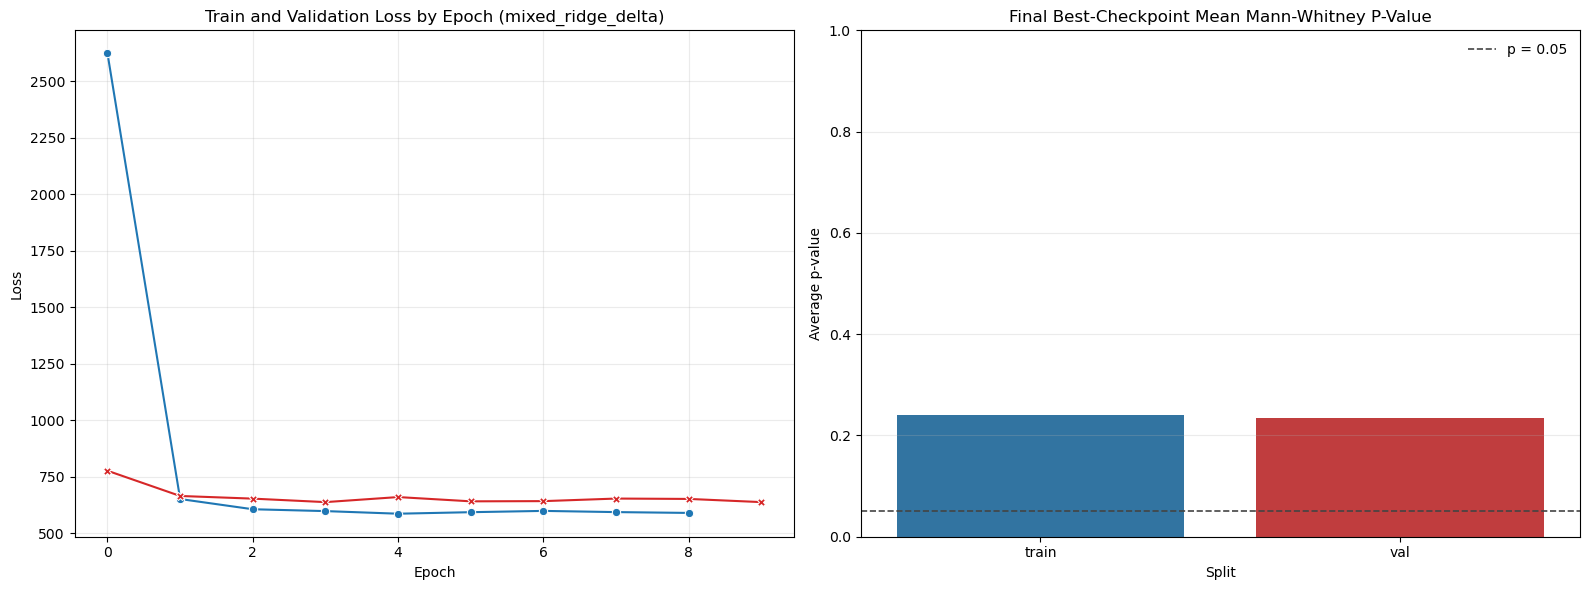

In [11]:
lightning_metrics_df = load_lightning_metrics_table(metrics_csv_path)
loss_history_df = build_loss_history_table(lightning_metrics_df)
train_val_mann_whitney_summary_df = (
    evaluation_summary_df.loc[evaluation_summary_df["split"].isin(["train", "val"])]
    .copy()
    .sort_values("split", key=lambda s: s.map({"train": 0, "val": 1}), ignore_index=True)
)

print(f"Loaded Lightning loss history from {metrics_csv_path}")
display(loss_history_df)
display(
    train_val_mann_whitney_summary_df[
        [
            "split",
            "mann_whitney_pvalue_mean",
            "mann_whitney_pvalue_median",
            "mann_whitney_not_significant_fraction",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
loss_ax, pvalue_ax = axes

sns.lineplot(
    data=loss_history_df,
    x="epoch",
    y="loss",
    hue="split",
    style="split",
    markers=True,
    dashes=False,
    palette={"train": "#1f77b4", "val": "#d62728"},
    ax=loss_ax,
)
loss_ax.set_title(f"Train and Validation Loss by Epoch ({run_name})")
loss_ax.set_xlabel("Epoch")
loss_ax.set_ylabel("Loss")
loss_ax.grid(True, alpha=0.25)
legend = loss_ax.get_legend()
if legend is not None:
    legend.remove()

sns.barplot(
    data=train_val_mann_whitney_summary_df,
    x="split",
    y="mann_whitney_pvalue_mean",
    hue="split",
    order=["train", "val"],
    hue_order=["train", "val"],
    palette={"train": "#1f77b4", "val": "#d62728"},
    dodge=False,
    legend=False,
    ax=pvalue_ax,
)
pvalue_ax.axhline(0.05, color="#444444", linestyle="--", linewidth=1.2, label="p = 0.05")
pvalue_ax.set_title("Final Best-Checkpoint Mean Mann-Whitney P-Value")
pvalue_ax.set_xlabel("Split")
pvalue_ax.set_ylabel("Average p-value")
pvalue_ax.set_ylim(0, max(1.0, float(train_val_mann_whitney_summary_df["mann_whitney_pvalue_mean"].max()) * 1.1))
pvalue_ax.grid(True, axis="y", alpha=0.25)
pvalue_ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()


## Plot Predicted vs Actual Test Pairs


Plotted 50 seeded_random test pairs with PCA using the best checkpoint.


,pair_index,condition_key,cell_line,drug,concentration,concentration_unit,treated_mse,delta_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue,pair_distance_2d
0,27,CVCL_0359|||Folic acid|||5|||uM,CVCL_0359,Folic acid,5.00,uM,9171.524414,9171.524414,0.987022,405972.0,1.084604e-08,2617.363281
1,35,CVCL_0371|||vincristine|||0.5|||uM,CVCL_0371,vincristine,0.50,uM,1553.991821,1553.991821,0.984777,538096.0,1.071196e-06,1166.767212
2,20,CVCL_0332|||Capmatinib|||5|||uM,CVCL_0332,Capmatinib,5.00,uM,2119.280762,2119.280518,0.957689,531267.0,1.487914e-05,1089.002075
3,34,CVCL_0371|||Riluzole hydrochloride|||0.05|||uM,CVCL_0371,Riluzole hydrochloride,0.05,uM,1123.207275,1123.207031,0.992817,454580.0,6.890514e-02,966.630615
4,29,CVCL_0359|||LY2090314|||0.5|||uM,CVCL_0359,LY2090314,0.50,uM,771.656860,771.656860,0.993421,448982.0,2.333242e-02,735.267151
5,23,CVCL_0332|||Sildenafil|||5|||uM,CVCL_0332,Sildenafil,5.00,uM,850.991150,850.991150,0.987964,494231.0,1.736680e-01,668.260376
6,33,CVCL_0371|||Methotrexate|||5|||uM,CVCL_0371,Methotrexate,5.00,uM,542.250000,542.250000,0.993475,484260.0,5.748436e-01,660.208618
7,9,CVCL_0131|||Arbutin|||5|||uM,CVCL_0131,Arbutin,5.00,uM,838.893677,838.893677,0.987302,562268.0,9.331947e-12,649.555664
8,21,CVCL_0332|||MK-3903|||0.05|||uM,CVCL_0332,MK-3903,0.05,uM,779.852173,779.852112,0.994059,431615.0,2.516034e-04,573.655457
9,30,CVCL_0359|||Verapamil|||0.05|||uM,CVCL_0359,Verapamil,0.05,uM,558.611145,558.611145,0.978786,524832.0,1.365016e-04,483.331970


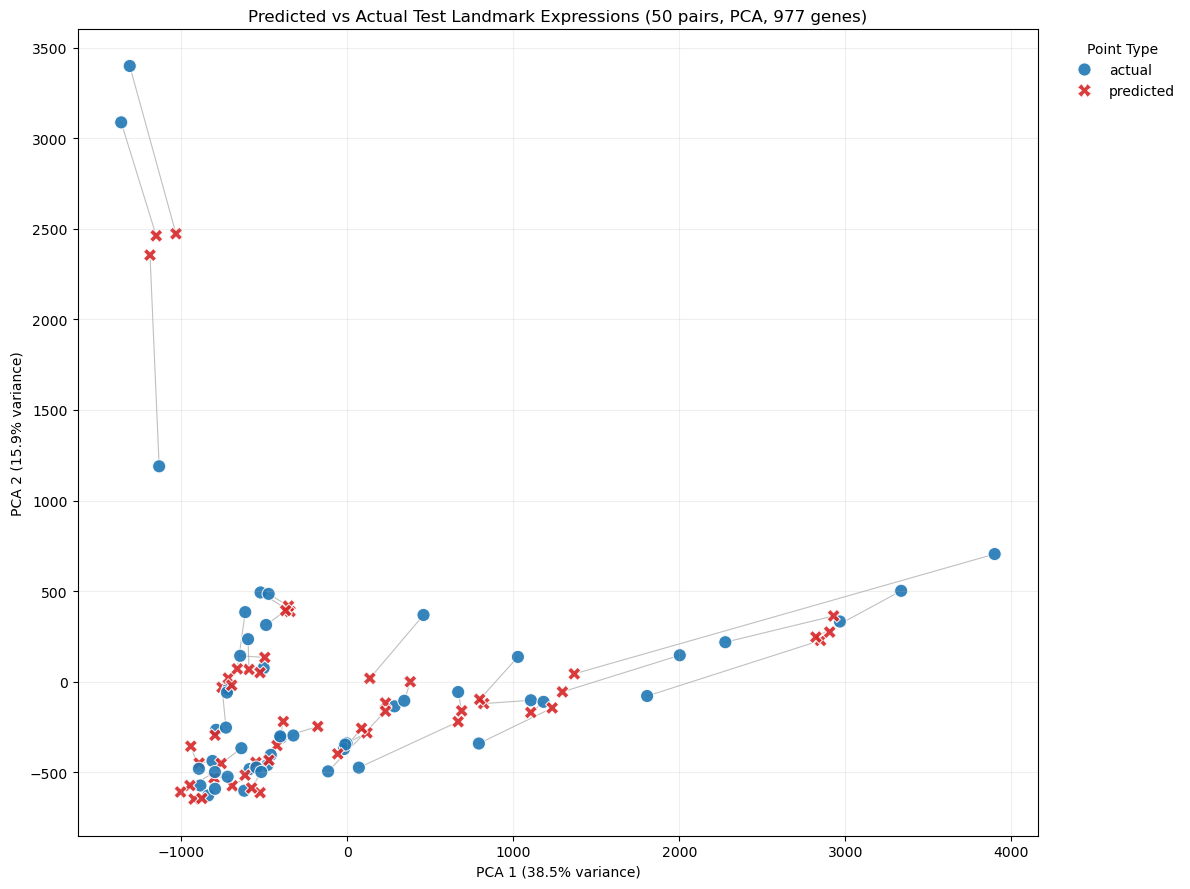

In [12]:
sampled_test_prediction_details_df = sample_prediction_details(
    prediction_details_df=test_prediction_details_df,
    sample_count=PLOT_TEST_SAMPLE_COUNT,
    sample_strategy=PLOT_TEST_SAMPLE_STRATEGY,
    random_seed=PLOT_RANDOM_SEED,
)
test_prediction_plot_df, sampled_test_pair_summary_df, test_embedding_explained_variance_ratio = build_prediction_pair_embedding(
    model=ridge_model,
    dataset=ridge_data_module.test_dataset,
    sampled_prediction_details_df=sampled_test_prediction_details_df,
    embedding_method=EMBEDDING_METHOD,
    n_components=N_EMBEDDING_COMPONENTS,
    random_seed=PLOT_RANDOM_SEED,
)

print(
    f"Plotted {len(sampled_test_prediction_details_df)} {PLOT_TEST_SAMPLE_STRATEGY} test pairs with {EMBEDDING_METHOD.upper()} using the best checkpoint."
)
display(sampled_test_pair_summary_df)

fig, ax = plt.subplots(figsize=(12, 9))
for pair_index, pair_points_df in test_prediction_plot_df.groupby("pair_index", sort=True):
    ordered_pair_points_df = pair_points_df.set_index("point_kind").loc[["actual", "predicted"]]
    ax.plot(
        ordered_pair_points_df["embedding_1"],
        ordered_pair_points_df["embedding_2"],
        color="#9e9e9e",
        linewidth=0.8,
        alpha=0.65,
        zorder=1,
    )

sns.scatterplot(
    data=test_prediction_plot_df,
    x="embedding_1",
    y="embedding_2",
    hue="point_kind",
    style="point_kind",
    palette={"actual": "#1f77b4", "predicted": "#d62728"},
    markers={"actual": "o", "predicted": "X"},
    s=90,
    alpha=0.9,
    ax=ax,
)

ax.set_title(
    f"Predicted vs Actual Test Landmark Expressions ({len(sampled_test_prediction_details_df)} pairs, {EMBEDDING_METHOD.upper()}, {len(target_gene_ids)} genes)"
)
ax.set_xlabel(f"PCA 1 ({test_embedding_explained_variance_ratio[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PCA 2 ({test_embedding_explained_variance_ratio[1] * 100:.1f}% variance)")
ax.grid(True, alpha=0.2)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Point Type")
fig.tight_layout()
plt.show()


## Plot Test Cell-Line Accuracy


Computed test-set cell-line accuracy using mann_whitney_pvalue > 0.05 as the correctness rule.


,cell_line,n_test_samples,n_correct_predictions,cell_line_accuracy
0,CVCL_0334,113,78,0.690265
1,CVCL_0099,91,59,0.648352
2,CVCL_0023,101,65,0.643564
3,CVCL_0546,119,76,0.638655
4,CVCL_0152,108,67,0.620370
5,CVCL_0504,100,61,0.610000
6,CVCL_0293,113,68,0.601770
7,CVCL_0366,112,67,0.598214
8,CVCL_0371,134,80,0.597015
9,CVCL_0399,118,69,0.584746


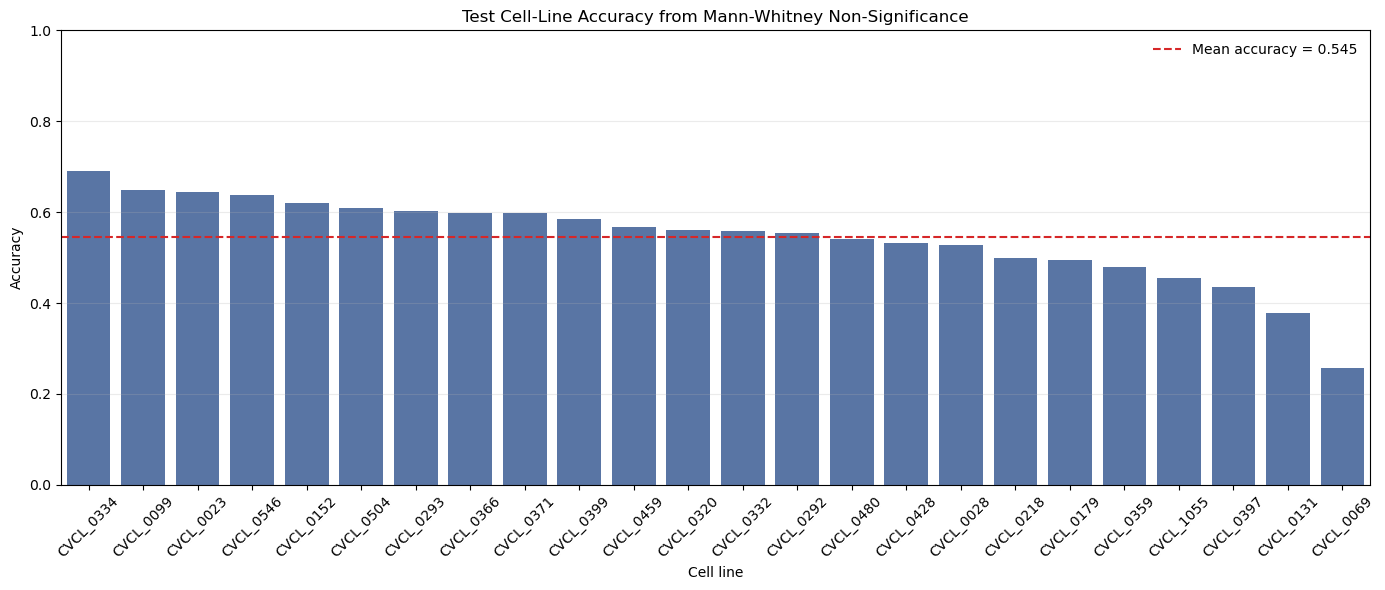

In [13]:
test_prediction_details_df = test_prediction_details_df.copy()
test_prediction_details_df["is_correct_prediction"] = test_prediction_details_df["mann_whitney_pvalue"] > 0.05

test_cell_line_accuracy_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        n_correct_predictions=("is_correct_prediction", "sum"),
    )
)
test_cell_line_accuracy_df["n_correct_predictions"] = test_cell_line_accuracy_df["n_correct_predictions"].astype(int)
test_cell_line_accuracy_df["cell_line_accuracy"] = (
    test_cell_line_accuracy_df["n_correct_predictions"] / test_cell_line_accuracy_df["n_test_samples"]
)
test_cell_line_accuracy_df = test_cell_line_accuracy_df.sort_values(
    ["cell_line_accuracy", "cell_line"],
    ascending=[False, True],
    ignore_index=True,
)
mean_cell_line_accuracy = float(test_cell_line_accuracy_df["cell_line_accuracy"].mean())

print("Computed test-set cell-line accuracy using mann_whitney_pvalue > 0.05 as the correctness rule.")
display(test_cell_line_accuracy_df)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=test_cell_line_accuracy_df,
    x="cell_line",
    y="cell_line_accuracy",
    color="#4c72b0",
    ax=ax,
)
ax.axhline(
    mean_cell_line_accuracy,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean accuracy = {mean_cell_line_accuracy:.3f}",
)
ax.set_title("Test Cell-Line Accuracy from Mann-Whitney Non-Significance")
ax.set_xlabel("Cell line")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()
